# 이커머스 리뷰 감성 분석기
**유형:** 이진 분류형 (임베딩 + SVM/로지스틱 회귀 비교)  
**목표:** 이커머스 리뷰를 입력하면 긍정/부정 감성을 예측하는 AI 만들기

---
### 데이터 출처
- **Steam 게임 리뷰** (100,000건) — 라벨: 0(부정), 1(긍정)
- **네이버 쇼핑 리뷰** (200,000건) — 별점 1-2→부정(0), 4-5→긍정(1)
- 두 데이터를 합쳐 `reviews_merged.csv` (300,000건)로 통합

### 라벨 정의
| 라벨 | 의미 | 데이터 비율 |
|------|------|-------------|
| 0 | 부정 리뷰 | ~50% |
| 1 | 긍정 리뷰 | ~50% |

### 이 노트북의 구조
| 단계 | 내용 |
|------|------|
| Step 1 | 데이터 로드 및 탐색 |
| Step 2 | 데이터 전처리 |
| Step 3 | 임베딩 & 분류기 학습 (모델 비교) |
| Step 4 | 예측 & 평가 |
| Step 5 | 미니 미션 |

### 왜 이커머스 리뷰 감성 분석이 중요한가?
이커머스 리뷰 데이터는 실제 소비자의 생생한 의견을 담고 있습니다:
- 수십만 건의 리뷰를 사람이 직접 읽고 분류하는 것은 비현실적
- 감성 분석으로 **상품별 만족도 추이**, **부정 리뷰 알림**, **VOC 자동 분류** 가능
- 쇼핑+게임 두 도메인의 데이터를 함께 학습하여 **도메인 일반화 능력** 확인

## Step 1: 데이터 로드 및 탐색

In [20]:
# =============================================================================
# 1. 필수 라이브러리 설치 및 임포트
# =============================================================================
# [의도] 이 프로젝트에서 사용하는 모든 외부 라이브러리를 설치하고 불러옵니다.
#   - sentence-transformers: 텍스트를 고차원 벡터(임베딩)로 변환하는 사전학습 모델 라이브러리
#   - scikit-learn: 분류기(LogisticRegression, SVM) 학습 및 성능 평가 도구
#   - torch: sentence-transformers의 내부 연산을 위한 딥러닝 프레임워크(PyTorch)
# =============================================================================
!pip install sentence-transformers scikit-learn torch

# re: 텍스트 전처리 시 정규표현식으로 노이즈를 제거하기 위해 사용
import re

# pandas: 표 형태의 데이터(DataFrame)를 다루기 위한 핵심 라이브러리
# numpy: 임베딩 벡터 등 수치 배열 연산에 사용
import pandas as pd
import numpy as np

# Counter: 텍스트 중복 빈도를 세어 데이터 품질을 확인할 때 사용
from collections import Counter

In [21]:
# =============================================================================
# 2. 이커머스 리뷰 데이터 로드 (CSV -> DataFrame)
# =============================================================================
# [의도] 사전에 합쳐 놓은 reviews_merged.csv를 로드하여 기본 분포를 확인합니다.
#
# [데이터 구조]
#   - text: 리뷰 텍스트 (한국어)
#   - label: 감성 라벨 (0=부정, 1=긍정)
#   - source: 데이터 출처 (steam / naver_shopping)
#
# [데이터 합성 과정] (reviews_merged.csv 생성 시)
#   - Steam: 원본 라벨(0/1)을 그대로 사용
#   - Naver Shopping: 별점 1-2 -> 0(부정), 별점 4-5 -> 1(긍정)으로 매핑
#   - 별점 3(중립)은 감성이 모호하므로 제외
# =============================================================================
raw_df = pd.read_csv("./Data/reviews_merged.csv")

print(f"전체 데이터: {len(raw_df):,}건\n")

# 소스별 분포: 두 데이터셋의 비율을 확인합니다.
print("=== 소스별 분포 ===")
print(raw_df["source"].value_counts())

# 라벨별 분포: 긍정/부정의 균형을 확인합니다.
# 불균형이 심하면 분류기가 다수 클래스로 편향될 수 있습니다.
print("\n=== 라벨 분포 ===")
label_counts = raw_df["label"].value_counts().sort_index()
label_counts.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in label_counts.index]
print(label_counts)

# 교차표: 소스별로 긍정/부정 비율이 다른지 확인합니다.
print("\n=== 소스 x 라벨 교차표 ===")
print(pd.crosstab(raw_df["source"], raw_df["label"], margins=True))

전체 데이터: 300,000건

=== 소스별 분포 ===
source
naver_shopping    200000
steam             100000
Name: count, dtype: int64

=== 라벨 분포 ===
0 (부정)    150041
1 (긍정)    149959
Name: count, dtype: int64

=== 소스 x 라벨 교차표 ===
label                0       1     All
source                                
naver_shopping  100037   99963  200000
steam            50004   49996  100000
All             150041  149959  300000


In [22]:
# =============================================================================
# 3. 원본 데이터 품질 확인 (전처리 전)
# =============================================================================
# [의도] 전처리를 적용하기 전에 원본 데이터의 품질 문제를 파악합니다.
# 이 분석 결과를 바탕으로 다음 셀에서 어떤 전처리를 적용할지 결정합니다.
# 확인하는 항목:
#   1) 텍스트 길이 분포: 너무 짧은 텍스트는 감성 판단 단서가 부족
#   2) 5자 미만 텍스트: "좋아", "별로" 같은 극히 짧은 리뷰
#   3) 중복 텍스트: 동일 리뷰가 반복되면 학습 데이터의 다양성이 감소
#   4) 소스별 텍스트 특성: Steam과 네이버 쇼핑의 리뷰 스타일 차이
# =============================================================================
print("=== 원본 데이터 품질 분석 ===\n")

# 텍스트 길이 통계: 리뷰의 전반적인 길이 분포를 파악합니다.
lengths = raw_df["text"].astype(str).str.len()
print(f"텍스트 길이 통계:")
print(f"  평균: {lengths.mean():.0f}자, 중앙값: {lengths.median():.0f}자")
print(f"  최소: {lengths.min()}자, 최대: {lengths.max()}자")

# 5자 미만 텍스트: 감성 판단에 필요한 정보가 부족한 극히 짧은 리뷰
# 이러한 텍스트는 전처리 단계에서 제거합니다.
short_mask = lengths < 5
print(f"\n5자 미만 텍스트: {short_mask.sum():,}건 ({short_mask.mean()*100:.1f}%)")
if short_mask.sum() > 0:
    print(f"  예시: {raw_df.loc[short_mask, 'text'].head(5).tolist()}")

# 중복 텍스트: 가장 많이 반복되는 리뷰를 확인합니다.
# 중복이 많으면 특정 표현에 과적합(overfitting)될 위험이 있습니다.
text_counter = Counter(raw_df["text"].astype(str))
print(f"\n가장 빈번한 텍스트 (중복 상위 5개):")
for text, count in text_counter.most_common(5):
    if count > 1:
        print(f"  [{count}회] {text[:50]}{'...' if len(text) > 50 else ''}")

# 소스별 텍스트 길이: 두 데이터셋의 리뷰 스타일 차이를 확인합니다.
# Steam 리뷰는 게임 경험을 서술하므로 비교적 길고,
# 네이버 쇼핑 리뷰는 간단한 한줄평이 많아 짧은 경향이 있습니다.
print(f"\n=== 소스별 텍스트 길이 ===")
for src in raw_df["source"].unique():
    src_lengths = raw_df[raw_df["source"] == src]["text"].astype(str).str.len()
    print(f"  {src:15s}: 평균 {src_lengths.mean():.0f}자, 중앙값 {src_lengths.median():.0f}자")

=== 원본 데이터 품질 분석 ===

텍스트 길이 통계:
  평균: 42자, 중앙값: 31자
  최소: 1자, 최대: 140자

5자 미만 텍스트: 2,051건 (0.7%)
  예시: ['우웩', '서든?', '구림', '개좋음', '쟝게파']

가장 빈번한 텍스트 (중복 상위 5개):
  [3회] 사지마세요
  [3회] 생각보다 그저그래요
  [2회] 컨텐츠가 없네
  [2회] 재미없다
  [2회] 이 세상 게임이 아니다

=== 소스별 텍스트 길이 ===
  steam          : 평균 47자, 중앙값 36자
  naver_shopping : 평균 40자, 중앙값 29자


## Step 2: 데이터 전처리

이커머스 리뷰 데이터는 사용자가 직접 작성한 텍스트이므로 다음과 같은 노이즈가 존재합니다:

| 문제 | 예시 | 해결 방법 |
|------|------|-----------|
| HTML 태그 | `<br>`, `<b>` | 정규표현식으로 제거 |
| 반복 문자 | "너무 좋아요ㅋㅋㅋㅋㅋㅋ" | 3자 이상 반복을 2자로 축소 |
| 극히 짧은 텍스트 | "좋아", "별로" | 5자 미만 제거 |
| 불필요한 공백 | "  리뷰 텍스트  " | strip + 다중 공백 제거 |
| 완전 중복 | 동일 텍스트 반복 | drop_duplicates |

In [23]:
# =============================================================================
# 4. 텍스트 전처리 함수 정의 + 데이터프레임 전처리
# =============================================================================
# [의도] 이커머스 리뷰에 특화된 텍스트 정제 규칙을 적용합니다.
#
# [고객문의 분류기와의 차이점]
#   고객문의 분류기에서는 콜센터 통화 녹취 텍스트의 특성에 맞춰
#   "네", "아 그래요?" 같은 추임새 필터와 ㅇㅇㅇ 익명화 토큰 제거가 필요했습니다.
#   이커머스 리뷰는 사용자 직접 작성이므로 추임새가 없지만,
#   대신 HTML 태그, 반복 문자(ㅋㅋㅋ), 이모티콘 등의 노이즈가 존재합니다.
#
# [최소 길이 기준: 5자]
#   고객문의 분류기에서는 15자였으나, 이커머스 리뷰는 "가격 대비 좋아요" 같은
#   짧은 한줄평도 의미가 있으므로 5자로 낮게 설정합니다.
# =============================================================================

def clean_text(text):
    """
    이커머스 리뷰 텍스트를 정제합니다.
    
    [처리 순서]
    1) 문자열 변환: NaN이나 숫자 등 비문자열 입력을 안전하게 처리
    2) HTML 태그 제거: <br>, <b>, <p> 등 웹에서 크롤링된 태그 잔여물 제거
    3) 반복 문자 축소: "ㅋㅋㅋㅋㅋ" -> "ㅋㅋ", "좋아요요요요" -> "좋아요요"
       3자 이상 연속 동일 문자를 2자로 축소하여 텍스트 정규화
    4) 공백 정리: 다중 공백 -> 단일 공백, 앞뒤 공백 제거
    
    Args:
        text: 원본 리뷰 텍스트
    Returns:
        정제된 텍스트 문자열
    """
    # NaN이나 숫자 등 비문자열 입력을 문자열로 변환합니다.
    text = str(text)
    
    # HTML 태그 제거: 웹 크롤링으로 수집된 데이터에 남아있는 태그를 제거합니다.
    # 예: "<br>줄바꿈" -> "줄바꿈", "<b>강조</b>" -> "강조"
    text = re.sub(r"<[^>]+>", "", text)
    
    # 반복 문자 축소: 같은 문자가 3회 이상 반복되면 2회로 줄입니다.
    # 예: "좋아요ㅋㅋㅋㅋㅋ" -> "좋아요ㅋㅋ"
    # 이모티콘이나 감탄사의 과도한 반복을 정규화하여 임베딩 품질을 높입니다.
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    
    # 다중 공백 -> 단일 공백: "좋은   제품" -> "좋은 제품"
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


def preprocess_dataframe(df, min_length=5):
    """
    DataFrame 전체에 전처리를 적용합니다.
    
    [처리 순서]
    1) clean_text()를 모든 텍스트에 적용
    2) 빈 문자열 제거
    3) min_length 미만 텍스트 제거 (감성 판단 단서 부족)
    4) 완전 중복 텍스트 제거 (과적합 방지)
    
    Args:
        df: text, label 컬럼이 있는 DataFrame
        min_length: 최소 텍스트 길이 (기본값 5)
    Returns:
        전처리된 DataFrame (원본은 변경하지 않음)
    """
    result = df.copy()
    original_len = len(result)
    
    # 모든 텍스트에 clean_text() 적용
    result["text"] = result["text"].apply(clean_text)
    
    # 빈 문자열 제거: clean_text 후 빈 문자열이 된 행을 제거합니다.
    result = result[result["text"].str.len() > 0]
    print(f"  -> 빈 텍스트 제거 후: {len(result):,}건 (-{original_len - len(result)})")
    
    # 최소 길이 미만 제거: 감성 판단에 필요한 최소한의 정보가 없는 텍스트를 제거합니다.
    before = len(result)
    result = result[result["text"].str.len() >= min_length]
    print(f"  -> {min_length}자 미만 제거 후: {len(result):,}건 (-{before - len(result):,})")
    
    # 완전 중복 제거: 동일한 텍스트가 여러 번 있으면 첫 번째만 남깁니다.
    before = len(result)
    result = result.drop_duplicates(subset="text", keep="first")
    print(f"  -> 중복 제거 후: {len(result):,}건 (-{before - len(result):,})")
    
    return result.reset_index(drop=True)


# 전처리 실행
print("데이터 전처리 중...")
print(f"  원본: {len(raw_df):,}건")
clean_df = preprocess_dataframe(raw_df, min_length=5)

데이터 전처리 중...
  원본: 300,000건
  -> 빈 텍스트 제거 후: 300,000건 (-0)
  -> 5자 미만 제거 후: 297,825건 (-2,175)
  -> 중복 제거 후: 297,641건 (-184)


In [24]:
# =============================================================================
# 5. 전처리 전후 비교
# =============================================================================
# [의도] 전처리가 데이터에 어떤 영향을 미쳤는지 확인합니다.
# 실제 텍스트 예시, 길이 변화, 라벨 분포 변화를 비교하여
# 전처리가 적절하게 수행되었는지 검증합니다.
# =============================================================================
print("=== 전처리 전 vs 후 비교 ===\n")

# 원본 vs 정제된 텍스트 비교: 실제 전처리 효과를 확인합니다.
print("전처리 전 (원본):")
for _, row in raw_df.head(3).iterrows():
    print(f"  [라벨:{row['label']}] {str(row['text'])[:80]}...")

print(f"\n전처리 후 (정제):")
for _, row in clean_df.head(3).iterrows():
    print(f"  [라벨:{row['label']}] {str(row['text'])[:80]}...")

# 텍스트 길이 비교: 전처리로 텍스트가 얼마나 변했는지 확인합니다.
raw_lengths = raw_df["text"].astype(str).str.len()
clean_lengths = clean_df["text"].astype(str).str.len()
print(f"\n텍스트 길이 비교:")
print(f"  전처리 전 -- 평균: {raw_lengths.mean():.0f}자, 중앙값: {raw_lengths.median():.0f}자")
print(f"  전처리 후 -- 평균: {clean_lengths.mean():.0f}자, 중앙값: {clean_lengths.median():.0f}자")

# 라벨 분포 변화: 전처리로 특정 라벨의 데이터가 편향되게 제거되지 않았는지 확인합니다.
print(f"\n전처리 후 라벨 분포:")
label_dist = clean_df["label"].value_counts().sort_index()
label_dist.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in label_dist.index]
print(label_dist)

=== 전처리 전 vs 후 비교 ===

전처리 전 (원본):
  [라벨:0] 노래가 너무 적음...
  [라벨:0] 돌겠네 진짜. 황숙아, 어크 공장 그만 돌려라. 죽는다....
  [라벨:1] 막노동 체험판 막노동 하는사람인데 장비를 내가 사야돼 뭐지...

전처리 후 (정제):
  [라벨:0] 노래가 너무 적음...
  [라벨:0] 돌겠네 진짜. 황숙아, 어크 공장 그만 돌려라. 죽는다....
  [라벨:1] 막노동 체험판 막노동 하는사람인데 장비를 내가 사야돼 뭐지...

텍스트 길이 비교:
  전처리 전 -- 평균: 42자, 중앙값: 31자
  전처리 후 -- 평균: 42자, 중앙값: 31자

전처리 후 라벨 분포:
0 (부정)    148782
1 (긍정)    148859
Name: count, dtype: int64


In [25]:
# =============================================================================
# 6. 균형 샘플링 + Train/Test 분할
# =============================================================================
# [의도] 전체 30만 건 중에서 학습과 평가에 사용할 데이터를 추출합니다.
#
# [왜 샘플링하는가?]
#   30만 건 전부를 임베딩하면 시간과 메모리가 과도하게 소요됩니다.
#   라벨당 균등하게 추출하여 효율적으로 학습하면서도 공정한 평가가 가능합니다.
#
# [샘플링 전략]
#   - Train: 라벨당 2,500건 x 2 = 5,000건 (균등 분포)
#   - Test: 라벨당 500건 x 2 = 1,000건 (균등 분포)
#   - stratify: 샘플링 시 라벨 비율을 유지하여 편향 방지
#
# [고객문의 분류기와의 차이점]
#   고객문의 분류기는 Training/Validation이 별도 파일로 제공되었지만,
#   이커머스 데이터는 하나의 CSV이므로 train_test_split으로 분할합니다.
# =============================================================================
from sklearn.model_selection import train_test_split

# 라벨당 샘플 수 설정
SAMPLE_PER_LABEL_TRAIN = 2500   # 학습용: 라벨당 2,500건
SAMPLE_PER_LABEL_TEST = 500     # 평가용: 라벨당 500건
TOTAL_PER_LABEL = SAMPLE_PER_LABEL_TRAIN + SAMPLE_PER_LABEL_TEST  # 3,000건

# [균등 샘플링 과정]
# 1) 각 라벨(0, 1)에서 TOTAL_PER_LABEL만큼 랜덤 추출
# 2) 두 라벨의 샘플을 합침
# 3) train_test_split으로 Train/Test 분할
sampled_dfs = []
for label in [0, 1]:
    subset = clean_df[clean_df["label"] == label]
    # random_state=42: 재현성을 위해 난수 시드를 고정합니다.
    # 같은 시드를 사용하면 항상 동일한 샘플이 추출됩니다.
    sampled_dfs.append(subset.sample(n=TOTAL_PER_LABEL, random_state=42))

sampled_df = pd.concat(sampled_dfs).reset_index(drop=True)

# [Train/Test 분할]
# stratify=sampled_df["label"]로 분할 시에도 라벨 비율을 유지합니다.
# test_size 계산: 전체에서 Test가 차지하는 비율
test_ratio = (SAMPLE_PER_LABEL_TEST * 2) / len(sampled_df)
train_df, test_df = train_test_split(
    sampled_df, 
    test_size=test_ratio,     # Test 비율
    stratify=sampled_df["label"],  # 라벨 비율 유지
    random_state=42           # 재현성 보장
)

print(f"최종 train: {len(train_df):,}건")
print(f"최종 test: {len(test_df):,}건")

# 분할된 데이터의 라벨 분포를 확인하여 균등한지 검증합니다.
print(f"\n=== Train 라벨 분포 ===")
train_label_dist = train_df["label"].value_counts().sort_index()
train_label_dist.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in train_label_dist.index]
print(train_label_dist)

print(f"\n=== Test 라벨 분포 ===")
test_label_dist = test_df["label"].value_counts().sort_index()
test_label_dist.index = [f"{i} ({'부정' if i == 0 else '긍정'})" for i in test_label_dist.index]
print(test_label_dist)

# 정제된 리뷰 예시 출력: 실제 학습할 텍스트의 내용을 확인합니다.
print(f"\n=== 전처리된 리뷰 예시 ===")
for label in [0, 1]:
    label_name = "부정" if label == 0 else "긍정"
    sample = train_df[train_df["label"] == label]["text"].iloc[0]
    print(f"\n [{label_name}]")
    print(f"   -> {sample[:100]}{'...' if len(sample) > 100 else ''}")

최종 train: 5,000건
최종 test: 1,000건

=== Train 라벨 분포 ===
0 (부정)    2500
1 (긍정)    2500
Name: count, dtype: int64

=== Test 라벨 분포 ===
0 (부정)    500
1 (긍정)    500
Name: count, dtype: int64

=== 전처리된 리뷰 예시 ===

 [부정]
   -> 재구매 사은품으로 일본에서 제조된걸 왜 주는거죠? 소비자들 전부 이거 사용해서 방사능 피폭됐으면 좋겠어서 주는건가? 놀라서 다른제품들 전부 일본제조인지 확인해봤어요 여러분들도 조심...

 [긍정]
   -> 예쁘고 튼튼한데 뚜껑 있는걸로 살껄 후회되네요.


---
## Step 3: 임베딩 & 분류기 학습

In [26]:
# =============================================================================
# 7. 임베딩 모델 로드 + 텍스트 임베딩
# =============================================================================
# [의도] 텍스트를 768차원 벡터로 변환하여 분류기가 학습할 수 있는 형태로 만듭니다.
#
# [임베딩이란?]
#   텍스트를 숫자 벡터로 변환하는 것을 임베딩(embedding)이라 합니다.
#   의미가 비슷한 텍스트는 벡터 공간에서 가까이 위치하게 됩니다.
#   예: "이 제품 정말 좋아요"와 "만족스러운 상품입니다"는 가까운 벡터가 됩니다.
#
# [모델 선택: paraphrase-multilingual-mpnet-base-v2]
#   - 768차원 벡터 생성 (MiniLM의 384차원보다 2배 넓은 벡터 공간)
#   - 50개 이상의 언어를 지원하는 다국어 모델 (한국어 포함)
#   - 고객문의 분류기 v3에서 사용한 것과 동일한 모델
#
# [embed_texts 함수]
#   대량의 텍스트를 배치(batch) 단위로 처리하여 메모리 효율적으로 임베딩합니다.
#   convert_to_numpy=True로 numpy 배열을 반환하여 scikit-learn과 호환됩니다.
# =============================================================================
from sentence_transformers import SentenceTransformer

# 사전학습된 다국어 임베딩 모델을 로드합니다.
# 첫 실행 시 모델을 다운로드하며, 이후에는 캐시에서 빠르게 로드됩니다.
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")


def embed_texts(texts, desc="임베딩"):
    """
    텍스트 리스트를 768차원 벡터 배열로 변환합니다.
    
    Args:
        texts: 변환할 텍스트 리스트
        desc: 진행 상황 표시 라벨
    Returns:
        numpy 배열 (n_texts, 768)
    """
    return model.encode(
        texts,
        convert_to_numpy=True,    # scikit-learn 호환을 위해 numpy 반환
        show_progress_bar=True,   # 진행 상황 표시 (대용량 데이터에 유용)
        batch_size=64             # GPU/CPU 메모리에 맞게 배치 크기 설정
    )


# [임베딩 실행]
# train_df와 test_df의 텍스트를 각각 벡터로 변환합니다.
# 5,000건: 약 30초, 1,000건: 약 5초 소요 (CPU 기준)
all_texts = train_df["text"].tolist()
print(f"train 임베딩 중... (768차원 MPNet 모델)")
X_train = embed_texts(all_texts, "train")

print(f"\ntest 임베딩 중...")
X_test = embed_texts(test_df["text"].tolist(), "test")

# 라벨 배열 생성: 분류기 학습에 사용할 정답 라벨
y_train = train_df["label"].values
y_test = test_df["label"].values

print(f"\n임베딩 shape: train {X_train.shape}, test {X_test.shape}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2266.90it/s, Materializing param=pooler.dense.weight]                               
XLMRobertaModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


train 임베딩 중... (768차원 MPNet 모델)


Batches: 100%|██████████| 79/79 [00:22<00:00,  3.56it/s]



test 임베딩 중...


Batches: 100%|██████████| 16/16 [00:04<00:00,  3.74it/s]


임베딩 shape: train (5000, 768), test (1000, 768)


In [27]:
# =============================================================================
# 8. 분류기 학습 + 모델 비교 (로지스틱 회귀 vs SVM)
# =============================================================================
# [의도] 두 가지 분류 알고리즘을 동일 데이터로 학습한 후 성능을 비교하고,
# 더 좋은 모델을 자동으로 선택합니다.
#
# [로지스틱 회귀 (Logistic Regression)]
#   - 각 클래스에 속할 확률을 선형적으로 계산하는 모델
#   - max_iter=2000: 수렴 실패 경고를 방지하기 위해 반복 횟수를 충분히 설정
#   - 장점: 학습 속도가 빠르고, 확률 해석이 직관적
#
# [SVM (Support Vector Machine)]
#   - RBF 커널을 사용하여 비선형 경계를 학습할 수 있는 모델
#   - C=10: 오분류 페널티를 높여 더 정확한 경계를 학습 (기본값 1보다 엄격)
#   - gamma='scale': 특성 수(768차원)에 맞게 자동 조정
#   - probability=True: predict_proba() 사용을 위해 확률 추정 활성화
#   - 장점: 고차원 데이터에서 강력한 분류 성능
#
# [자동 선택 로직]
#   Test 데이터에 대한 Accuracy가 더 높은 모델을 최종 분류기로 선택합니다.
#   이후 예측 함수에서 이 분류기를 사용합니다.
# =============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# [1] 로지스틱 회귀 학습
print("[1/2] 로지스틱 회귀 학습 중...")
clf_lr = LogisticRegression(max_iter=2000, random_state=42)
clf_lr.fit(X_train, y_train)
y_pred_lr = clf_lr.predict(X_test)
acc_lr = (y_pred_lr == y_test).mean()
print(f"   -> Accuracy: {acc_lr:.4f}")

# [2] SVM (RBF 커널) 학습
print("[2/2] SVM (RBF) 학습 중...")
clf_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
clf_svm.fit(X_train, y_train)
y_pred_svm = clf_svm.predict(X_test)
acc_svm = (y_pred_svm == y_test).mean()
print(f"   -> Accuracy: {acc_svm:.4f}")

# [자동 선택] 더 높은 Accuracy의 모델을 최종 분류기로 선택합니다.
if acc_lr >= acc_svm:
    clf, y_pred, acc, best_name = clf_lr, y_pred_lr, acc_lr, "로지스틱 회귀"
else:
    clf, y_pred, acc, best_name = clf_svm, y_pred_svm, acc_svm, "SVM (RBF)"

print(f"\n최종 선택: {best_name} (Accuracy: {acc:.4f})")

# [분류 리포트]
# precision, recall, f1-score를 라벨별로 보여줍니다.
# - precision: 긍정이라고 예측한 것 중 실제 긍정의 비율
# - recall: 실제 긍정 중 올바르게 긍정으로 예측한 비율
# - f1-score: precision과 recall의 조화평균
label_names = ["부정 (0)", "긍정 (1)"]
print(f"\n=== 분류 리포트 ({best_name}) ===")
print(classification_report(y_test, y_pred, target_names=label_names))

[1/2] 로지스틱 회귀 학습 중...
   -> Accuracy: 0.8180
[2/2] SVM (RBF) 학습 중...
   -> Accuracy: 0.8050

최종 선택: 로지스틱 회귀 (Accuracy: 0.8180)

=== 분류 리포트 (로지스틱 회귀) ===
              precision    recall  f1-score   support

      부정 (0)       0.80      0.85      0.82       500
      긍정 (1)       0.84      0.79      0.81       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



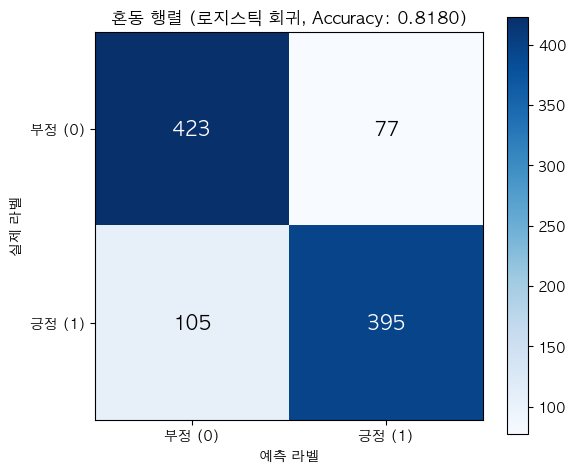


라벨별 정확도:
  부정 (0): 423/500 (84.6%)
  긍정 (1): 395/500 (79.0%)


In [28]:
# =============================================================================
# 9. 혼동 행렬 시각화
# =============================================================================
# [의도] 분류기의 예측 결과를 2x2 행렬로 시각화하여
# 어떤 유형의 오분류가 발생하는지 직관적으로 파악합니다.
#
# [혼동 행렬 해석]
#   행(row) = 실제 라벨, 열(column) = 예측 라벨
#   - (0,0): 실제 부정 -> 부정 예측 (True Negative) -- 올바른 분류
#   - (0,1): 실제 부정 -> 긍정 예측 (False Positive) -- 부정을 긍정으로 잘못 분류
#   - (1,0): 실제 긍정 -> 부정 예측 (False Negative) -- 긍정을 부정으로 잘못 분류
#   - (1,1): 실제 긍정 -> 긍정 예측 (True Positive) -- 올바른 분류
# =============================================================================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib

# [한글 폰트 설정]
# matplotlib의 기본 폰트는 한글을 지원하지 않으므로,
# macOS의 AppleGothic 폰트를 지정하여 한글 깨짐을 방지합니다.
# unicode_minus=False로 마이너스 기호가 깨지는 문제도 해결합니다.
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# [혼동 행렬 계산]
cm = confusion_matrix(y_test, y_pred)

# [히트맵 시각화]
classes = ["부정 (0)", "긍정 (1)"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(xticks=range(len(classes)), yticks=range(len(classes)),
       xticklabels=classes, yticklabels=classes,
       ylabel='실제 라벨', xlabel='예측 라벨',
       title=f'혼동 행렬 ({best_name}, Accuracy: {acc:.4f})')

# [셀 안에 숫자 표시]
# 각 셀에 건수를 직접 표시하여 정확한 값을 확인할 수 있게 합니다.
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black", fontsize=14)

plt.tight_layout()
plt.show()

# [라벨별 정확도 요약]
print(f"\n라벨별 정확도:")
for i, cls in enumerate(classes):
    correct = cm[i, i]
    total = cm[i].sum()
    print(f"  {cls}: {correct}/{total} ({correct/total*100:.1f}%)")

---
## Step 4: 예측 & 평가

In [10]:
# =============================================================================
# 10. 예측 함수 정의 (새로운 리뷰의 감성을 분류)
# =============================================================================
# [의도] 학습이 완료된 분류기를 사용하여 새로운 리뷰 텍스트의
# 감성(긍정/부정)을 예측하는 함수를 정의합니다.
#
# [핵심 포인트 - 전처리 일관성]
#   입력 텍스트에도 학습 데이터와 동일한 clean_text() 전처리를 적용합니다.
#   학습 시 전처리된 텍스트로 임베딩을 생성했으므로,
#   예측 시에도 같은 전처리를 거쳐야 임베딩 공간에서 올바른 위치에 매핑됩니다.
#
# [predict_proba의 역할]
#   일반 predict()는 가장 확률이 높은 클래스 하나만 반환하지만,
#   predict_proba()는 모든 클래스에 대한 확률 분포를 반환합니다.
#   [p_부정, p_긍정] 형태로 반환되어 분류기의 "확신 정도"를 파악할 수 있습니다.
# =============================================================================
def predict_sentiment(text: str):
    """
    리뷰 텍스트를 입력받아 긍정/부정 감성을 예측합니다.
    
    [처리 흐름]
    1) clean_text()로 입력 텍스트 전처리
    2) 임베딩 모델로 벡터 변환
    3) 분류기로 긍정/부정 확률 계산
    4) 결과를 막대 그래프로 시각화
    
    Args:
        text: 분류할 리뷰 텍스트 (원본 그대로 입력)
    """
    # 입력 텍스트에 학습 데이터와 동일한 전처리를 적용합니다.
    cleaned = clean_text(text)
    
    # 전처리된 텍스트를 768차원 벡터로 변환합니다.
    emb = model.encode([cleaned], convert_to_numpy=True)
    
    # 분류기를 통해 각 클래스에 속할 확률을 계산합니다.
    # probs = [p_부정, p_긍정]
    probs = clf.predict_proba(emb)[0]
    
    # 가장 확률이 높은 클래스를 예측 결과로 선택합니다.
    pred_label = np.argmax(probs)
    sentiment = "긍정" if pred_label == 1 else "부정"

    # [결과 출력]
    print("\n" + "=" * 50)
    print(" 리뷰 내용:")
    print(f"   {text}")
    if cleaned != text:
        print(f"   (전처리 후: {cleaned[:60]}{'...' if len(cleaned)>60 else ''})")
    print("=" * 50)
    
    # 감성별 확률을 시각적 막대 그래프로 출력합니다.
    print(f"\n 예측 결과: [{sentiment}]")
    labels = ["부정", "긍정"]
    for i, label in enumerate(labels):
        p = probs[i]
        bar = "█" * int(p * 30)  # 확률에 비례하는 길이의 막대 생성
        print(f"   {label} {bar} ({p:.3f})")
    print("=" * 50 + "\n")

In [11]:
# =============================================================================
# 테스트: 명확한 리뷰 3건으로 분류기 동작 확인
# =============================================================================
# [의도] 긍정/부정이 명확한 리뷰를 입력하여
# 분류기가 올바르게 작동하는지 기본적인 검증을 수행합니다.
#
# [테스트 케이스 선정 기준]
# 사람이 보기에도 감성이 명확한 문장을 선택하여,
# 분류기의 기본적인 판별 능력을 먼저 확인합니다.
# 두 도메인(쇼핑/게임) 모두 테스트합니다.
# =============================================================================

# 테스트 1: 긍정 쇼핑 리뷰 (만족, 추천 키워드)
print(">>> 테스트 1: 긍정 쇼핑 리뷰")
predict_sentiment("배송도 빠르고 품질도 좋아요. 가격 대비 만족합니다. 추천!")

# 테스트 2: 부정 쇼핑 리뷰 (불량, 실망 키워드)
print(">>> 테스트 2: 부정 쇼핑 리뷰")
predict_sentiment("사진이랑 너무 다르고 품질이 별로예요. 돈 아까워요.")

# 테스트 3: 긍정 게임 리뷰 (재미, 최고 키워드)
print(">>> 테스트 3: 긍정 게임 리뷰")
predict_sentiment("그래픽이 미쳤고 스토리 몰입감이 장난 아닙니다. 올해 최고의 게임!")

>>> 테스트 1: 긍정 쇼핑 리뷰

 리뷰 내용:
   배송도 빠르고 품질도 좋아요. 가격 대비 만족합니다. 추천!

 예측 결과: [긍정]
   부정  (0.005)
   긍정 █████████████████████████████ (0.995)

>>> 테스트 2: 부정 쇼핑 리뷰

 리뷰 내용:
   사진이랑 너무 다르고 품질이 별로예요. 돈 아까워요.

 예측 결과: [부정]
   부정 █████████████████████████████ (0.997)
   긍정  (0.003)

>>> 테스트 3: 긍정 게임 리뷰

 리뷰 내용:
   그래픽이 미쳤고 스토리 몰입감이 장난 아닙니다. 올해 최고의 게임!

 예측 결과: [긍정]
   부정 █████ (0.168)
   긍정 ████████████████████████ (0.832)



---
## Step 5: 미니 미션

### 미션 1: 직접 리뷰 작성하기
긍정/부정 리뷰를 직접 작성하고, AI가 올바르게 분류하는지 확인하세요.

In [12]:
# =============================================================================
# 미션 1-1: 긍정 쇼핑 리뷰 작성
# =============================================================================
# [의도] 쇼핑 상품에 대한 긍정적인 리뷰를 직접 작성하여
# 분류기가 올바르게 "긍정"으로 판별하는지 확인합니다.
# =============================================================================
my_review_1 = "포장이 꼼꼼하고 제품 상태도 완벽해요. 재구매 의사 있습니다!"
predict_sentiment(my_review_1)
# 예상한 감성: 긍정
# AI의 예측이 맞았나요?: 


 리뷰 내용:
   포장이 꼼꼼하고 제품 상태도 완벽해요. 재구매 의사 있습니다!

 예측 결과: [긍정]
   부정 █ (0.039)
   긍정 ████████████████████████████ (0.961)



In [13]:
# =============================================================================
# 미션 1-2: 부정 게임 리뷰 작성
# =============================================================================
# [의도] 게임에 대한 부정적인 리뷰를 작성하여 분류기를 테스트합니다.
# 쇼핑 리뷰와 다른 도메인(게임)에서도 감성 판별이 정확한지 확인합니다.
# =============================================================================
my_review_2 = "버그가 너무 많고 최적화가 안 돼서 렉이 심해요. 환불하고 싶습니다."
predict_sentiment(my_review_2)
# 예상한 감성: 부정
# AI의 예측이 맞았나요?: 


 리뷰 내용:
   버그가 너무 많고 최적화가 안 돼서 렉이 심해요. 환불하고 싶습니다.

 예측 결과: [부정]
   부정 █████████████████████████████ (0.993)
   긍정  (0.007)



In [14]:
# =============================================================================
# 미션 1-3: 중립적 리뷰 작성
# =============================================================================
# [의도] 긍정과 부정이 섞인 중립적인 리뷰를 작성하여 분류기를 테스트합니다.
# 이 분류기는 이진 분류(긍정/부정)만 하므로 중립은 없지만,
# 중립적인 텍스트를 입력했을 때 확률이 어떻게 분포되는지 관찰합니다.
# =============================================================================
my_review_3 = "보통이에요. 가격은 괜찮은데 품질이 아쉬워요. 그래도 쓸 만은 합니다."
predict_sentiment(my_review_3)
# 예상한 감성: 긍정/부정 어느 쪽?
# AI의 예측이 적절한가요?: 


 리뷰 내용:
   보통이에요. 가격은 괜찮은데 품질이 아쉬워요. 그래도 쓸 만은 합니다.

 예측 결과: [긍정]
   부정 ██████████ (0.342)
   긍정 ███████████████████ (0.658)



### 미션 2: 경계가 애매한 리뷰 만들기
감성이 **모호하거나 반어적인** 리뷰를 만들어보세요.  
예: "가격만 아니면 최고인데..." -> 긍정? 부정?

In [15]:
# =============================================================================
# 미션 2-1: 반어법 리뷰
# =============================================================================
# [의도] 표면적으로는 긍정적이지만 실제로는 부정적인 반어법 리뷰를 입력하여
# 분류기가 반어법을 이해할 수 있는지 테스트합니다.
# 반어법은 텍스트 감성 분석의 대표적인 난제 중 하나입니다.
# =============================================================================
ambiguous_1 = "와 정말 대단하네요. 이렇게 별로인 제품도 팔다니. 역시 최고입니다."
predict_sentiment(ambiguous_1)
# 실제 감성: 부정 (반어법)
# AI 예측이 적절한가요?: 


 리뷰 내용:
   와 정말 대단하네요. 이렇게 별로인 제품도 팔다니. 역시 최고입니다.

 예측 결과: [긍정]
   부정 █████ (0.170)
   긍정 ████████████████████████ (0.830)



In [16]:
# =============================================================================
# 미션 2-2: 조건부 긍정 리뷰
# =============================================================================
# [의도] "~만 아니면 좋은데"와 같이 조건이 붙은 긍정 리뷰를 테스트합니다.
# 전체적으로는 긍정적이지만 특정 불만 사항이 명시되어 있어
# 분류기가 어떤 쪽으로 판단하는지 관찰합니다.
# =============================================================================
ambiguous_2 = "디자인은 예쁜데 배터리가 너무 빨리 닳아요. 가격만 아니면 좋은 제품이에요."
predict_sentiment(ambiguous_2)
# 실제 감성: 긍부정 혼합
# AI 예측이 적절한가요?: 


 리뷰 내용:
   디자인은 예쁜데 배터리가 너무 빨리 닳아요. 가격만 아니면 좋은 제품이에요.

 예측 결과: [부정]
   부정 ██████████████████████████ (0.877)
   긍정 ███ (0.123)



In [17]:
# =============================================================================
# 미션 2-3: 긍정 단어 + 부정 문맥 리뷰
# =============================================================================
# [의도] "재미있다", "좋다" 같은 긍정 단어가 포함되어 있지만
# 부정적인 맥락에서 사용된 리뷰를 테스트합니다.
# 단어 수준이 아닌 문맥 수준의 감성 이해가 필요한 사례입니다.
# =============================================================================
ambiguous_3 = "처음에는 재미있었는데 갈수록 반복되는 내용이라 지루해져요. 돈이 아깝네요."
predict_sentiment(ambiguous_3)
# 실제 감성: 부정 (긍정 단어가 포함되어 있지만 전체적으로 부정)
# AI 예측이 적절한가요?: 


 리뷰 내용:
   처음에는 재미있었는데 갈수록 반복되는 내용이라 지루해져요. 돈이 아깝네요.

 예측 결과: [부정]
   부정 █████████████████████████ (0.865)
   긍정 ████ (0.135)



### 미션 3: AI 확신도 분석
`predict_sentiment`는 긍정/부정 확률을 보여줍니다.

- 한쪽 확률이 0.8 이상 -> AI가 **확신**하는 것
- 두 확률이 비슷(0.4~0.6) -> AI가 **헷갈리는** 것

이 두 가지 경우를 각각 찾아보세요.

In [18]:
# =============================================================================
# 미션 3-1: AI가 확신하는 리뷰 (한쪽 확률 0.8 이상 목표)
# =============================================================================
# [의도] 분류기가 높은 확신을 가지는 리뷰를 작성합니다.
# "최고", "강추", "별점 5점" 같은 명확한 긍정 키워드가 포함된
# 문장일수록 확신도가 높아집니다.
# =============================================================================
certain_review = "인생템입니다. 진짜 이거 안 사면 후회해요. 강력 추천!"
predict_sentiment(certain_review)
# 긍정 확률: 


 리뷰 내용:
   인생템입니다. 진짜 이거 안 사면 후회해요. 강력 추천!

 예측 결과: [긍정]
   부정 ███ (0.116)
   긍정 ██████████████████████████ (0.884)



In [19]:
# =============================================================================
# 미션 3-2: AI가 헷갈리는 리뷰 (두 확률 차이 0.1 이하 목표)
# =============================================================================
# [의도] 분류기가 확신하지 못하는 리뷰를 작성합니다.
# 긍정과 부정이 균등하게 섞여 있어 한쪽으로 결정하기 어려운 문장이
# 대표적인 예시입니다.
# 이런 경우가 실무에서 발생하면 사람이 최종 판단해야 합니다.
# =============================================================================
uncertain_review = "나쁘지는 않은데 그렇다고 좋지도 않아요. 그냥 그래요."
predict_sentiment(uncertain_review)
# 두 확률의 차이: 


 리뷰 내용:
   나쁘지는 않은데 그렇다고 좋지도 않아요. 그냥 그래요.

 예측 결과: [부정]
   부정 ███████████████████████████ (0.909)
   긍정 ██ (0.091)



### 미션 4: 실제 업무 활용 아이디어
이 감성 분석기를 실제 이커머스 플랫폼에 적용한다면 어떻게 활용할 수 있을까요?

In [ ]:
# =============================================================================
# 미션 4: 실제 업무 활용 아이디어
# =============================================================================
# [의도] 기술적 구현을 넘어, 이 감성 분석기가 실제 비즈니스 환경에서
# 어떻게 활용될 수 있는지 생각해보는 확장 과제입니다.
# 기술의 한계와 가능성을 함께 고려하여 현실적인 활용 방안을 모색합니다.
# =============================================================================
#
# 1. 이 감성 분석기를 이커머스 플랫폼에 적용하면 어떤 점이 좋을까요?
#    -> 
#
# 2. 분류 정확도를 높이려면 어떤 방법이 있을까요? (2가지 이상)
#    -> 
#
# 3. 긍정/부정 외에 추가하면 좋을 감성 카테고리가 있다면?
#    -> 
#
# 4. 이 감성 분석기의 한계점은 무엇일까요?
#    -> 